In [11]:
import pandas as pd
from pathlib import Path

# Automatically find the raw survey Excel file in your Jupyter folder
files = list(Path.cwd().glob("*Responses*.xlsx"))

if not files:
    raise FileNotFoundError(
        "Excel file not found. Please put the survey Excel file "
        "in the same folder as this Jupyter Notebook."
    )

file_path = files[0]

print("Using Excel file:")
print(file_path)

df = pd.read_excel(file_path, sheet_name="Form Responses 1")

print("Shape:", df.shape)
print("\nColumns:")
for i, c in enumerate(df.columns, start=1):
    print(i, ":", c)

Using Excel file:
E:\JAVA FULL STACK--\ML & AI\0-MBA\A Study on Adoption of AI Techniques for Demand Forecasting among Textile Manufacturing Units in Tiruppur, Tamil Nadu (Responses) (1).xlsx
Shape: (75, 37)

Columns:
1 : Timestamp
2 : 1. Is your current workplace located in Tiruppur, Tamil Nadu?
3 : 2. What is your current designation?
4 : 3. How many years of experience do you have in the textile industry?
5 : 4. What is the primary activity of your organization?
6 : 5. What is the approximate size of your organization?
7 : 6. Does your organization currently use demand forecasting for production planning?
8 : 7. What is the primary method used for demand forecasting in your organization?
9 : 8. How frequently is demand forecasting performed?
10 : 9. Which information is primarily used for demand forecasting?
11 : 10. Which factor has the greatest influence on demand variation in your organization?
12 : 11. How would you describe the effectiveness of the current demand forecasting pr

Using Excel file: E:\JAVA FULL STACK--\ML & AI\0-MBA\A Study on Adoption of AI Techniques for Demand Forecasting among Textile Manufacturing Units in Tiruppur, Tamil Nadu (Responses) (1).xlsx
Shape: (75, 37)

Q16 detected as: 16. Which statement best describes your organization's current level of AI adoption?

Predictors used: 21
- 2. What is your current designation?
- 3. How many years of experience do you have in the textile industry?
- 4. What is the primary activity of your organization?
- 5. What is the approximate size of your organization?
- 6. Does your organization currently use demand forecasting for production planning?
- 7. What is the primary method used for demand forecasting in your organization?
- 8. How frequently is demand forecasting performed?
- 9. Which information is primarily used for demand forecasting?
- 10. Which factor has the greatest influence on demand variation in your organization?
- 11. How would you describe the effectiveness of the current demand for

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


 Multinomial Logistic Regression
Fold accuracies: [0.6    0.4667 0.3333 0.4    0.4667]
Mean accuracy: 0.4533
Std. deviation: 0.0884

 Random Forest
Fold accuracies: [0.6667 0.6    0.6667 0.4    0.4667]
Mean accuracy: 0.56
Std. deviation: 0.1083

MODEL COMPARISON


,Model,Mean CV Accuracy,Std. Deviation
0,Multinomial Logistic Regression,0.453333,0.088443
1,Random Forest,0.560000,0.108321



Random Forest OOF Accuracy: 0.56


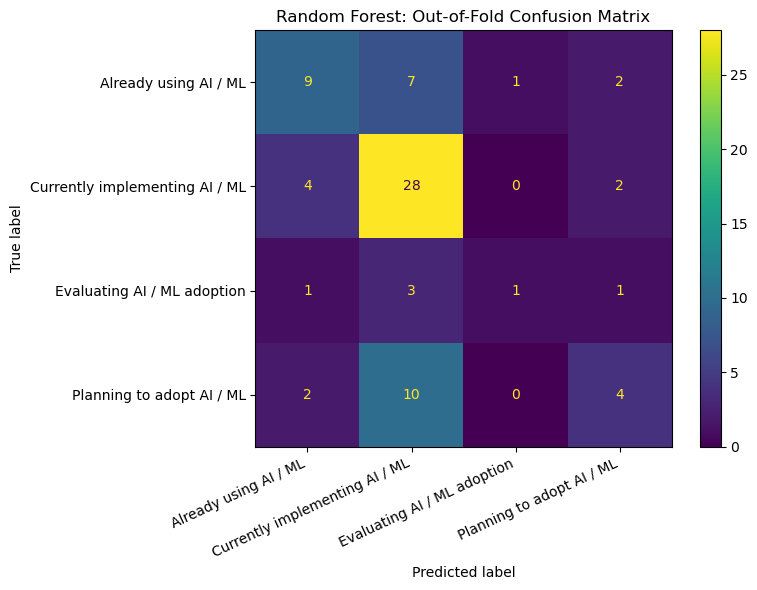


TOP QUESTION-LEVEL PREDICTORS


,Question,Importance_Mean,Importance_SD
0,17. In which business area is AI / analytics c...,0.037333,0.050465
1,12. How would you describe your awareness of A...,0.028000,0.067396
2,15. Through which source have you mainly learn...,0.028000,0.049755
3,24. What is the current level of management su...,0.021333,0.019664
4,20. What is the current level of technological...,0.020000,0.040000
5,11. How would you describe the effectiveness o...,0.014667,0.084116
6,25. What level of investment would your organi...,0.009333,0.037298
7,14. Which AI / analytics application are you m...,0.008000,0.050640
8,8. How frequently is demand forecasting perfor...,0.006667,0.026247
9,6. Does your organization currently use demand...,0.004000,0.052409


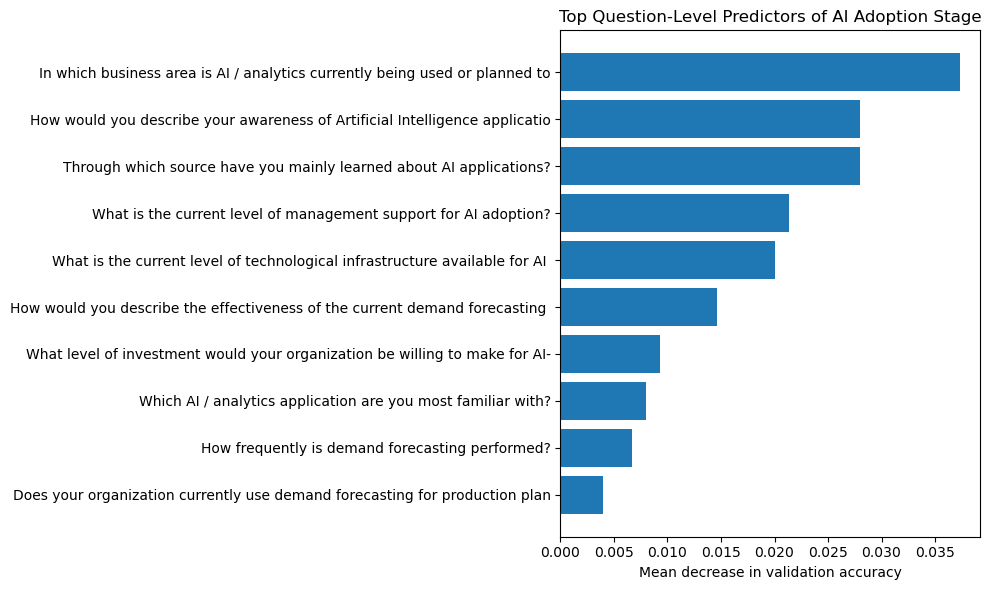


REPORT INTERPRETATION

This is exploratory predictive analytics. The target is the survey-reported
AI/ML adoption stage (Question 16), NOT textile demand.

The model should be reported using the observed mean 5-fold cross-validation
accuracy. Random Forest is preferred here only because it produced the higher
observed cross-validated accuracy in this sample.

The corrected permutation importance is calculated on held-out validation
folds, so it should be interpreted as predictive importance rather than causal
influence.

Because the sample contains only 68 responses and the target has four adoption
categories, the results should not be treated as proof of causality or as
evidence that AI forecasting is more accurate than traditional forecasting.

Actual AI demand forecasting requires historical demand time-series data
(e.g., monthly product/market demand), which is outside the present survey
dataset and can be proposed as a future extension.



In [12]:

# MBA Business Analytics Project
# AI Techniques for Demand Forecasting among Textile Manufacturing Units in Tiruppur, Tamil Nadu
# Exploratory Predictive Analytics: AI Adoption Stage

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Load the survey workbook
# ------------------------------------------------------------
files = list(Path.cwd().glob("*Responses*.xlsx"))

if not files:
    raise FileNotFoundError(
        "Excel file not found. Put the survey Excel file in the same folder as this notebook."
    )

file_path = files[0]
print("Using Excel file:", file_path)

df = pd.read_excel(file_path, sheet_name="Form Responses 1")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Detect questionnaire columns by question number
# ------------------------------------------------------------
def question_number(col):
    m = re.match(r"\s*(\d+)\.", str(col))
    return int(m.group(1)) if m else None

q_cols = {question_number(c): c for c in df.columns if question_number(c) is not None}

if 16 not in q_cols:
    raise ValueError("Question 16 could not be detected.")

target_col = q_cols[16]
print("\nQ16 detected as:", target_col)

# Predictors intentionally stop before post-adoption outcome questions.
# Q18 is excluded because it can directly reflect the adoption state in Q16.
predictor_numbers = list(range(2, 16)) + [17, 20, 21, 22, 23, 24, 25]
predictor_cols = [q_cols[n] for n in predictor_numbers if n in q_cols]

print("\nPredictors used:", len(predictor_cols))
for c in predictor_cols:
    print("-", c)

# ------------------------------------------------------------
# 3. Clean modelling sample
# ------------------------------------------------------------
X = df[predictor_cols].copy()
y = df[target_col].astype(str).str.strip()

valid = y.notna() & y.ne("") & y.ne("nan")
X = X.loc[valid].copy()
y = y.loc[valid].copy()

print("\nFinal modelling sample:", len(y))
print("\nTarget distribution:")
print(y.value_counts())

# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
], remainder="drop")

log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000, multi_class="multinomial", random_state=42))
])

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=2
    ))
])

# ------------------------------------------------------------
# 5. Stratified 5-fold cross-validation
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in [
    ("Multinomial Logistic Regression", log_model),
    ("Random Forest", rf_model)
]:
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print("\n", name)
    print("Fold accuracies:", np.round(scores, 4))
    print("Mean accuracy:", round(scores.mean(), 4))
    print("Std. deviation:", round(scores.std(), 4))
    results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std. Deviation": scores.std()
    })

comparison = pd.DataFrame(results)
print("\nMODEL COMPARISON")
display(comparison)

comparison.to_csv("ML_Model_Comparison.csv", index=False)

# ------------------------------------------------------------
# 6. Out-of-fold Random Forest predictions
# ------------------------------------------------------------
rf_oof = cross_val_predict(
    rf_model, X, y, cv=cv, method="predict"
)

rf_oof_accuracy = accuracy_score(y, rf_oof)
print("\nRandom Forest OOF Accuracy:", round(rf_oof_accuracy, 4))

labels = sorted(y.unique())
cm = confusion_matrix(y, rf_oof, labels=labels)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", ax=plt.gca())
plt.title("Random Forest: Out-of-Fold Confusion Matrix")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Corrected question-level permutation importance
#    IMPORTANT: importance is measured on unseen validation folds.
# ------------------------------------------------------------
importance_rows = []

for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    model = rf_model
    model.fit(X_train, y_train)

    baseline = accuracy_score(y_test, model.predict(X_test))

    for col in X.columns:
        drops = []
        for repeat in range(10):
            X_perm = X_test.copy()
            rng = np.random.default_rng(1000 + fold_no * 100 + repeat)
            X_perm[col] = rng.permutation(X_perm[col].to_numpy())
            perm_score = accuracy_score(y_test, model.predict(X_perm))
            drops.append(baseline - perm_score)

        importance_rows.append({
            "Question": col,
            "Fold": fold_no,
            "Importance": np.mean(drops)
        })

importance_long = pd.DataFrame(importance_rows)

importance_summary = (
    importance_long
    .groupby("Question")["Importance"]
    .agg(Importance_Mean="mean", Importance_SD="std")
    .sort_values("Importance_Mean", ascending=False)
    .reset_index()
)

print("\nTOP QUESTION-LEVEL PREDICTORS")
display(importance_summary.head(15))

importance_summary.to_csv("ML_Feature_Importance.csv", index=False)

# ------------------------------------------------------------
# 8. Optional feature-importance chart
# ------------------------------------------------------------
top = importance_summary.head(10).sort_values("Importance_Mean")

plt.figure(figsize=(10, 6))
plt.barh(
    [re.sub(r"^\d+\.\s*", "", q)[:75] for q in top["Question"]],
    top["Importance_Mean"]
)
plt.xlabel("Mean decrease in validation accuracy")
plt.title("Top Question-Level Predictors of AI Adoption Stage")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. MBA-ready interpretation
# ------------------------------------------------------------
best = comparison.sort_values("Mean CV Accuracy", ascending=False).iloc[0]

print("""
REPORT INTERPRETATION

This is exploratory predictive analytics. The target is the survey-reported
AI/ML adoption stage (Question 16), NOT textile demand.

The model should be reported using the observed mean 5-fold cross-validation
accuracy. Random Forest is preferred here only because it produced the higher
observed cross-validated accuracy in this sample.

The corrected permutation importance is calculated on held-out validation
folds, so it should be interpreted as predictive importance rather than causal
influence.

Because the sample contains only 68 responses and the target has four adoption
categories, the results should not be treated as proof of causality or as
evidence that AI forecasting is more accurate than traditional forecasting.

Actual AI demand forecasting requires historical demand time-series data
(e.g., monthly product/market demand), which is outside the present survey
dataset and can be proposed as a future extension.
""")


In [13]:
plt.savefig(
    "Figure_4_1_Random_Forest_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [14]:
plt.tight_layout()

plt.savefig(
    "Figure_4_2_Top_AI_Adoption_Predictors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>